# Early Satellite Collision-Risk Prediction Using Temporal Conjunction Data

This project investigates whether information from multiple historical Conjunction Data Messages (CDMs) can help identify high-risk satellite conjunction events earlier than using a single available CDM.

The analysis uses the ESA Kelvins Collision Avoidance Challenge dataset and compares single-CDM and temporal information at different lead times before the Time of Closest Approach (TCA).

## 1. Dataset Loading

In [81]:
# Import required libraries

import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,precision_score,recall_score,fbeta_score,average_precision_score)

Mount Google Drive:

In [82]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Extract Dataset

In [83]:
zip_path = '/content/drive/MyDrive/Space project/Collision Avoidance Challenge - Dataset.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

### Extract Training Data

In [84]:
zip_path = '/content/dataset/Collision Avoidance Challenge - Dataset/kelvins_competition_data/train_data.zip'
extract_path = '/content/dataset/train_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

### Load Training Dataset

In [85]:
df = pd.read_csv('/content/dataset/train_data/train_data.csv')

# 2. Dataset Understanding

In [86]:
print("="*60)
print("DATASET BASIC INFO")
print("="*60)
print(f"Shape (rows, columns): {df.shape}")
print(f"Number of unique events: {df['event_id'].nunique()}")
print()

print("First 5 rows of key columns:")
print(df[['event_id', 'time_to_tca', 'risk', 'miss_distance', 'mission_id']].head())
print()

print("Data types of key columns:")
print(df[['event_id', 'time_to_tca', 'risk', 'miss_distance']].dtypes)
print()

print("Missing values in key columns:")
print(df[['event_id', 'time_to_tca', 'risk', 'miss_distance', 'mission_id']].isnull().sum())
print()

print("Basic statistics of time_to_tca and risk:")
print(df[['time_to_tca', 'risk']].describe())

DATASET BASIC INFO
Shape (rows, columns): (162634, 103)
Number of unique events: 13154

First 5 rows of key columns:
   event_id  time_to_tca       risk  miss_distance  mission_id
0         0     1.566798 -10.204955        14923.0           5
1         0     1.207494 -10.355758        14544.0           5
2         0     0.952193 -10.345631        14475.0           5
3         0     0.579669 -10.337809        14579.0           5
4         0     0.257806 -10.391260        14510.0           5

Data types of key columns:
event_id           int64
time_to_tca      float64
risk             float64
miss_distance    float64
dtype: object

Missing values in key columns:
event_id         0
time_to_tca      0
risk             0
miss_distance    0
mission_id       0
dtype: int64

Basic statistics of time_to_tca and risk:
         time_to_tca           risk
count  162634.000000  162634.000000
mean        3.350190     -19.340603
std         2.013114      10.011641
min        -0.149808     -30.000000


## 3. Understanding CDMs as Time-Series Data

Each event contains multiple Conjunction Data Messages (CDMs) describing the same potential encounter at different points in time.

Therefore, the CDMs associated with an event are treated as a sequence rather than as completely independent observations.

In [87]:
print("="*60)
print("HOW MANY CDMs PER EVENT?")
print("="*60)

cdms_per_event = df.groupby('event_id').size()

print(cdms_per_event.describe())
print()

print("Number of events with only 1 CDM:", (cdms_per_event == 1).sum())
print("Number of events with ≥ 5 CDMs:", (cdms_per_event >= 5).sum())
print("Number of events with ≥ 10 CDMs:", (cdms_per_event >= 10).sum())
print()

print("First 10 event sizes:")
print(cdms_per_event.head(10))
print()

# Checking the time range for a few events
print("="*60)
print("EXAMPLE: Time evolution of one event (event_id = 0)")
print("="*60)
example = df[df['event_id'] == 0][['time_to_tca', 'risk', 'miss_distance']].sort_values('time_to_tca', ascending=False)
print(example)

HOW MANY CDMs PER EVENT?
count    13154.000000
mean        12.363844
std          7.512551
min          1.000000
25%          5.000000
50%         13.000000
75%         20.000000
max         23.000000
dtype: float64

Number of events with only 1 CDM: 225
Number of events with ≥ 5 CDMs: 9996
Number of events with ≥ 10 CDMs: 7496

First 10 event sizes:
event_id
0     5
1     4
2    20
3    21
4     9
5    20
6    21
7     7
8    20
9    20
dtype: int64

EXAMPLE: Time evolution of one event (event_id = 0)
   time_to_tca       risk  miss_distance
0     1.566798 -10.204955        14923.0
1     1.207494 -10.355758        14544.0
2     0.952193 -10.345631        14475.0
3     0.579669 -10.337809        14579.0
4     0.257806 -10.391260        14510.0


## 4. Defining the Early Prediction Window

The final risk of each conjunction event is obtained from the final CDM in the event sequence.

To investigate early prediction, the initial analysis uses only CDMs available at least 2 days before the Time of Closest Approach (TCA).

In [88]:
# 1. Sort so that within each event, the latest CDM comes last
df = df.sort_values(['event_id', 'time_to_tca'], ascending=[True, False]).reset_index(drop=True)

# 2. Create final_risk = risk of the last CDM in each event
df['final_risk'] = df.groupby('event_id')['risk'].transform('last')

# 3. Keep only CDMs that are available ≥ 2 days before TCA
df_early = df[df['time_to_tca'] >= 2.0].copy()

print("="*60)
print("AFTER FILTERING TO EARLY WINDOW (≥ 2 days before TCA)")
print("="*60)
print(f"Original number of rows: {len(df)}")
print(f"Rows remaining in early window: {len(df_early)}")
print(f"Unique events remaining: {df_early['event_id'].nunique()}")
print()

print("CDMs per event in the early window:")
print(df_early.groupby('event_id').size().describe())
print()

print("Final risk statistics (log10 scale):")
print(df_early.groupby('event_id')['final_risk'].first().describe())
print()

print("Sample of the new dataframe (first 8 rows):")
print(df_early[['event_id', 'time_to_tca', 'risk', 'final_risk', 'miss_distance']].head(8))

AFTER FILTERING TO EARLY WINDOW (≥ 2 days before TCA)
Original number of rows: 162634
Rows remaining in early window: 111939
Unique events remaining: 11942

CDMs per event in the early window:
count    11942.000000
mean         9.373556
std          5.224646
min          1.000000
25%          4.000000
50%         10.000000
75%         15.000000
max         17.000000
dtype: float64

Final risk statistics (log10 scale):
count    11942.000000
mean       -23.198562
std          9.510903
min        -30.000000
25%        -30.000000
50%        -30.000000
75%        -13.587918
max         -1.684660
Name: final_risk, dtype: float64

Sample of the new dataframe (first 8 rows):
    event_id  time_to_tca       risk  final_risk  miss_distance
5          1     6.530455  -7.561299   -9.248105         2392.0
6          1     5.561646  -9.315693   -9.248105         3587.0
7          1     5.226504  -7.422508   -9.248105         7882.0
8          1     3.570013  -9.248105   -9.248105        26899.0
9   

## 5. Risk Evolution from Early to Final Assessment

The analysis examines how collision risk changes across an event and how much conjunction information is available within the early prediction window.

In [89]:
# Take the earliest available CDM for each event in the early window
# (the one with the largest time_to_tca)
earliest = df_early.loc[df_early.groupby('event_id')['time_to_tca'].idxmax()]

# Calculate the change
earliest = earliest.copy()
earliest['risk_change'] = earliest['final_risk'] - earliest['risk']

print("="*60)
print("RISK CHANGE ANALYSIS (Final risk - Earliest risk)")
print("="*60)
print(earliest['risk_change'].describe())
print()

print("How many events had risk increase (positive change):", (earliest['risk_change'] > 0).sum())
print("How many events had risk decrease (negative change):", (earliest['risk_change'] < 0).sum())
print("How many events had almost no change (|change| < 0.5):", (earliest['risk_change'].abs() < 0.5).sum())
print()

print("Sample of events with biggest risk increase:")
print(earliest.nlargest(5, 'risk_change')[['event_id', 'time_to_tca', 'risk', 'final_risk', 'risk_change']])
print()

print("Sample of events with biggest risk decrease:")
print(earliest.nsmallest(5, 'risk_change')[['event_id', 'time_to_tca', 'risk', 'final_risk', 'risk_change']])

RISK CHANGE ANALYSIS (Final risk - Earliest risk)
count    11942.000000
mean       -10.958049
std         10.849721
min        -27.834866
25%        -20.837131
50%        -15.309202
75%         -0.000284
max         25.910358
Name: risk_change, dtype: float64

How many events had risk increase (positive change): 1776
How many events had risk decrease (negative change): 8966
How many events had almost no change (|change| < 0.5): 2952

Sample of events with biggest risk increase:
        event_id  time_to_tca  risk  final_risk  risk_change
117460      9488     6.121693 -30.0   -4.089642    25.910358
30342       2450     5.639485 -30.0   -5.047062    24.952938
85457       6910     6.485407 -30.0   -5.162475    24.837525
83487       6748     5.433285 -30.0   -5.328642    24.671358
121780      9851     4.768441 -30.0   -5.366128    24.633872

Sample of events with biggest risk decrease:
        event_id  time_to_tca      risk  final_risk  risk_change
82869       6694     4.745144 -2.165134 

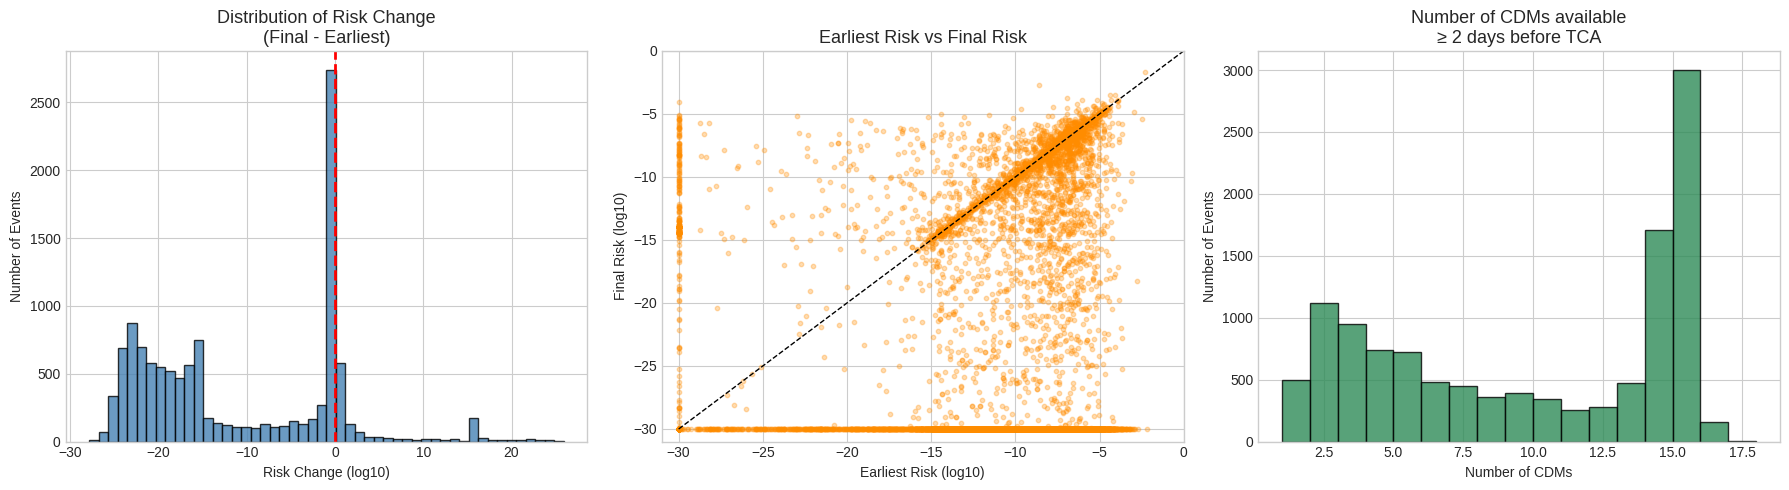

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribution of risk change
axes[0].hist(earliest['risk_change'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title("Distribution of Risk Change\n(Final - Earliest)", fontsize=13)
axes[0].set_xlabel("Risk Change (log10)")
axes[0].set_ylabel("Number of Events")

# Plot 2: Earliest risk vs Final risk
axes[1].scatter(earliest['risk'], earliest['final_risk'], alpha=0.3, s=10, color='darkorange')
axes[1].plot([-30, 0], [-30, 0], 'k--', linewidth=1)  # perfect agreement line
axes[1].set_title("Earliest Risk vs Final Risk", fontsize=13)
axes[1].set_xlabel("Earliest Risk (log10)")
axes[1].set_ylabel("Final Risk (log10)")
axes[1].set_xlim(-31, 0)
axes[1].set_ylim(-31, 0)

# Plot 3: How many CDMs we have in early window
cdm_counts = df_early.groupby('event_id').size()
axes[2].hist(cdm_counts, bins=range(1, 19), color='seagreen', edgecolor='black', alpha=0.8)
axes[2].set_title("Number of CDMs available\n≥ 2 days before TCA", fontsize=13)
axes[2].set_xlabel("Number of CDMs")
axes[2].set_ylabel("Number of Events")

plt.tight_layout()
plt.show()

## 6. High-Risk vs Low-Risk Event Behaviour

In [91]:
# Create a simple label
earliest['is_high_risk'] = earliest['final_risk'] >= -6

print("="*60)
print("HIGH-RISK vs LOW-RISK SUMMARY")
print("="*60)
print("Number of High-risk events (final_risk ≥ -6):", earliest['is_high_risk'].sum())
print("Number of Low-risk events (final_risk < -6):", (~earliest['is_high_risk']).sum())
print()

print("Average risk change:")
print(earliest.groupby('is_high_risk')['risk_change'].mean())
print()

print("Average earliest risk:")
print(earliest.groupby('is_high_risk')['risk'].mean())
print()

print("Average final risk:")
print(earliest.groupby('is_high_risk')['final_risk'].mean())

HIGH-RISK vs LOW-RISK SUMMARY
Number of High-risk events (final_risk ≥ -6): 323
Number of Low-risk events (final_risk < -6): 11619

Average risk change:
is_high_risk
False   -11.307970
True      1.629365
Name: risk_change, dtype: float64

Average earliest risk:
is_high_risk
False   -12.386529
True     -6.987992
Name: risk, dtype: float64

Average final risk:
is_high_risk
False   -23.694499
True     -5.358627
Name: final_risk, dtype: float64


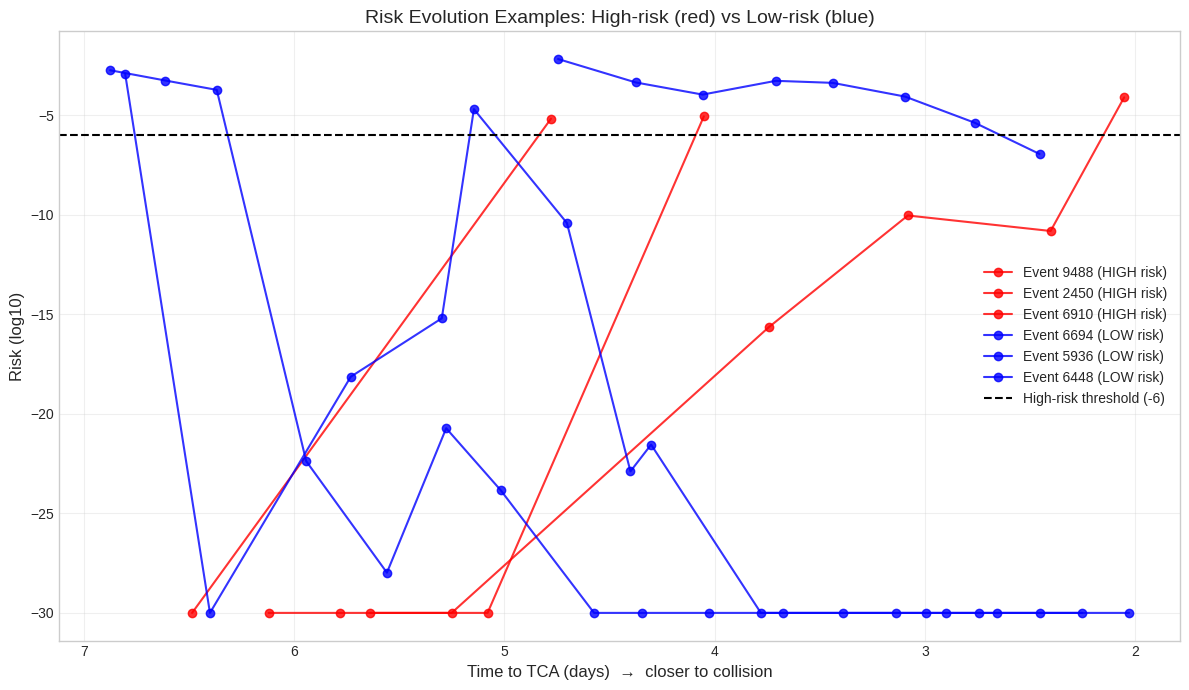

In [92]:
# Select a few interesting events
high_risk_ids = earliest[earliest['is_high_risk']].nlargest(3, 'risk_change')['event_id'].values
low_risk_ids  = earliest[~earliest['is_high_risk']].nsmallest(3, 'risk_change')['event_id'].values

example_ids = list(high_risk_ids) + list(low_risk_ids)

plt.figure(figsize=(12, 7))

for eid in example_ids:
    event_data = df_early[df_early['event_id'] == eid].sort_values('time_to_tca', ascending=False)

    is_high = earliest.loc[earliest['event_id'] == eid, 'is_high_risk'].values[0]
    label = f"Event {eid} ({'HIGH' if is_high else 'LOW'} risk)"
    color = 'red' if is_high else 'blue'

    plt.plot(event_data['time_to_tca'], event_data['risk'],
             marker='o', label=label, color=color, alpha=0.8)

plt.axhline(-6, color='black', linestyle='--', linewidth=1.5, label='High-risk threshold (-6)')
plt.gca().invert_xaxis()  # so time moves from left (early) to right (closer to TCA)
plt.xlabel("Time to TCA (days)  →  closer to collision", fontsize=12)
plt.ylabel("Risk (log10)", fontsize=12)
plt.title("Risk Evolution Examples: High-risk (red) vs Low-risk (blue)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Event-Level Feature Construction

In [93]:
# We work only with the early window data
features = df_early.groupby('event_id').agg(
    # Basic info
    num_cdms = ('time_to_tca', 'count'),
    first_time = ('time_to_tca', 'max'),          # earliest CDM time
    last_time = ('time_to_tca', 'min'),           # latest early CDM time

    # Risk related
    earliest_risk = ('risk', 'first'),            # risk of the earliest CDM
    latest_early_risk = ('risk', 'last'),         # risk of the most recent early CDM
    mean_risk = ('risk', 'mean'),
    min_risk = ('risk', 'min'),
    max_risk = ('risk', 'max'),

    # Miss distance
    earliest_miss = ('miss_distance', 'first'),
    mean_miss = ('miss_distance', 'mean'),

    # Final risk (our target)
    final_risk = ('final_risk', 'first')
).reset_index()

# Add risk change features
features['risk_change_early'] = features['latest_early_risk'] - features['earliest_risk']

# High-risk label
features['is_high_risk'] = features['final_risk'] >= -6

print("="*60)
print("FEATURES CREATED SUCCESSFULLY")
print("="*60)
print(f"Number of events with features: {len(features)}")
print()
print("Columns we now have:")
print(features.columns.tolist())
print()
print("Sample of the new features table:")
print(features.head(8))

FEATURES CREATED SUCCESSFULLY
Number of events with features: 11942

Columns we now have:
['event_id', 'num_cdms', 'first_time', 'last_time', 'earliest_risk', 'latest_early_risk', 'mean_risk', 'min_risk', 'max_risk', 'earliest_miss', 'mean_miss', 'final_risk', 'risk_change_early', 'is_high_risk']

Sample of the new features table:
   event_id  num_cdms  first_time  last_time  earliest_risk  \
0         1         4    6.530455   3.570013      -7.561299   
1         2        14    6.983474   2.340627     -10.816161   
2         3        15    6.950088   2.278941      -9.568315   
3         4         3    4.966244   3.066467      -7.870632   
4         5        14    6.790114   2.103772      -6.189767   
5         6        15    6.733984   2.040187     -12.156892   
6         7         5    6.535121   2.531723     -13.050269   
7         8        14    6.552403   2.285275      -6.077586   

   latest_early_risk  mean_risk   min_risk   max_risk  earliest_miss  \
0          -9.248105  -8.38

CORRELATION WITH FINAL RISK (sorted by strength)
latest_early_risk    0.707500
min_risk             0.698627
mean_risk            0.545174
risk_change_early    0.544621
last_time            0.529946
num_cdms            -0.417779
earliest_risk        0.194254
max_risk             0.184756
first_time          -0.069840
mean_miss            0.009499
earliest_miss        0.001663
Name: final_risk, dtype: float64



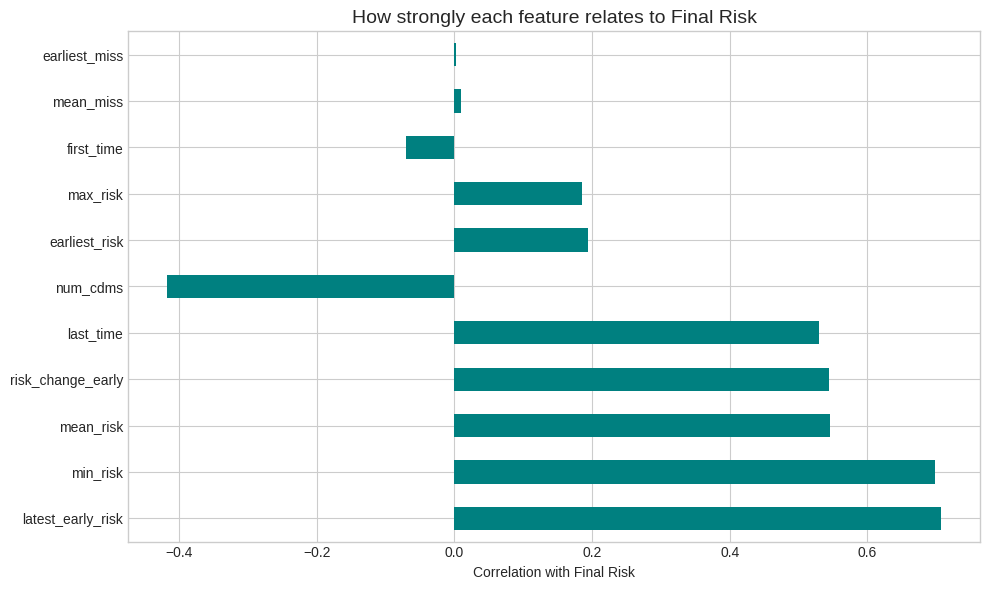

In [94]:
# Select numerical features only
feature_cols = ['num_cdms', 'first_time', 'last_time','earliest_risk', 'latest_early_risk', 'mean_risk','min_risk', 'max_risk', 'earliest_miss', 'mean_miss','risk_change_early']

# Calculate correlation with final_risk
correlations = features[feature_cols + ['final_risk']].corr()['final_risk'].drop('final_risk')
correlations = correlations.sort_values(key=abs, ascending=False)

print("="*60)
print("CORRELATION WITH FINAL RISK (sorted by strength)")
print("="*60)
print(correlations)
print()

# Simple bar plot
plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color='teal')
plt.title("How strongly each feature relates to Final Risk", fontsize=14)
plt.xlabel("Correlation with Final Risk")
plt.tight_layout()
plt.show()

## 8. Event-Level Random Forest Baseline

In [95]:
# Features we will use (only early information)
X_cols = ['num_cdms', 'earliest_risk', 'latest_early_risk', 'mean_risk','min_risk', 'max_risk', 'risk_change_early', 'earliest_miss', 'mean_miss']

X = features[X_cols]
y = features['is_high_risk']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Train a simple Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight='balanced',   # important because high-risk events are rare
    random_state=42
)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Low-risk', 'High-risk']))
print()
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

MODEL PERFORMANCE
              precision    recall  f1-score   support

    Low-risk       1.00      0.98      0.99      2905
   High-risk       0.53      0.93      0.68        81

    accuracy                           0.98      2986
   macro avg       0.76      0.95      0.83      2986
weighted avg       0.99      0.98      0.98      2986


ROC-AUC Score: 0.982

Confusion Matrix:
[[2839   66]
 [   6   75]]


FEATURE IMPORTANCE (what the model used most)
latest_early_risk    0.477878
mean_risk            0.176219
max_risk             0.136143
min_risk             0.102241
risk_change_early    0.036686
earliest_risk        0.036254
num_cdms             0.012086
mean_miss            0.011510
earliest_miss        0.010984
dtype: float64


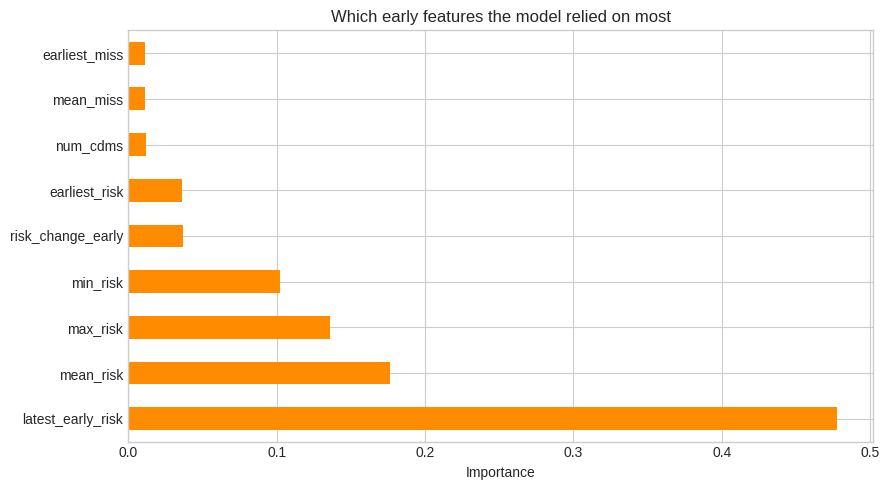

In [96]:
importance = pd.Series(model.feature_importances_, index=X_cols)
importance = importance.sort_values(ascending=False)

print("="*60)
print("FEATURE IMPORTANCE (what the model used most)")
print("="*60)
print(importance)

plt.figure(figsize=(9, 5))
importance.plot(kind='barh', color='darkorange')
plt.title("Which early features the model relied on most")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. Lead-Time Feature Preparation

In [97]:

def prepare_features(df, lead_time):
    """
    Prepare features for a given lead time (e.g. 4.0 means 4 days before TCA).
    Only uses CDMs where time_to_tca >= lead_time.
    Returns one row per event with:
    - Single CDM features (from the latest available CDM)
    - Temporal/evolution features (from all available CDMs)
    """

    # 1. Keep only CDMs available at the selected lead time or earlier
    df_lead = df[df['time_to_tca'] >= lead_time].copy()

    if df_lead.empty:
        return None

    # 2. Sort so the latest CDM (smallest time_to_tca) comes last
    df_lead = df_lead.sort_values(['event_id', 'time_to_tca'], ascending=[True, False])

    # 3. Single-CDM features (only from the most recent CDM at this lead time)
    single = df_lead.groupby('event_id').agg(
        single_risk = ('risk', 'last'),
        single_miss = ('miss_distance', 'last'),
        single_time = ('time_to_tca', 'last')
    )

    # 4. Temporal / evolution features (using all CDMs available up to this lead time)
    temporal = df_lead.groupby('event_id').agg(
        num_cdms = ('risk', 'count'),
        mean_risk = ('risk', 'mean'),
        min_risk = ('risk', 'min'),
        max_risk = ('risk', 'max'),
        first_risk = ('risk', 'first'),
        risk_change = ('risk', lambda x: x.iloc[-1] - x.iloc[0] if len(x) > 1 else 0),
        mean_miss = ('miss_distance', 'mean')
    )

    # 5. Final risk (target) - this is okay because it is the LABEL, not a feature
    target = df.groupby('event_id')['risk'].last().rename('final_risk')

    # 6. Combine everything
    features = single.join(temporal).join(target)
    features['is_high_risk'] = features['final_risk'] >= -6
    features['lead_time'] = lead_time

    # Remove events that have no CDM at this lead time
    features = features.dropna(subset=['single_risk'])

    return features.reset_index()


# Check feature preparation at 2-day lead time
print("Testing the function with lead_time = 2.0 ...")
test_features = prepare_features(df, lead_time=2.0)

print(f"Number of events: {len(test_features)}")
print(f"High-risk events: {test_features['is_high_risk'].sum()}")
print("\nSample of features:")
print(test_features.head())

Testing the function with lead_time = 2.0 ...
Number of events: 11942
High-risk events: 323

Sample of features:
   event_id  single_risk  single_miss  single_time  num_cdms  mean_risk  \
0         1    -9.248105      26899.0     3.570013         4  -8.386902   
1         2   -30.000000      18763.0     2.340627        14 -27.261902   
2         3   -30.000000      23900.0     2.278941        15 -20.422318   
3         4   -30.000000      33593.0     3.066467         3 -15.279741   
4         5   -13.100070        304.0     2.103772        14  -5.827374   

    min_risk   max_risk  first_risk  risk_change     mean_miss  final_risk  \
0  -9.315693  -7.422508   -7.561299    -1.686806  10190.000000   -9.248105   
1 -30.000000 -10.816161  -10.816161   -19.183839  19442.357143  -30.000000   
2 -30.000000  -9.412177   -9.568315   -20.431685  26478.466667  -30.000000   
3 -30.000000  -7.870632   -7.870632   -22.129368  32825.666667  -27.650917   
4 -13.100070  -4.049879   -6.189767    -6.9103

## 10. Preparing Features Across Lead Times

In [98]:
lead_times = [6.0, 5.0, 4.0, 3.0, 2.0]

all_features = {}

for lt in lead_times:
    print(f"Preparing features for lead time = {lt} days...")
    feats = prepare_features(df, lead_time=lt)
    all_features[lt] = feats
    print(f"   → Events available: {len(feats)} | High-risk: {feats['is_high_risk'].sum()}")

print("\nDone! Features ready for all lead times.")

Preparing features for lead time = 6.0 days...
   → Events available: 8426 | High-risk: 206
Preparing features for lead time = 5.0 days...
   → Events available: 9484 | High-risk: 248
Preparing features for lead time = 4.0 days...
   → Events available: 10481 | High-risk: 285
Preparing features for lead time = 3.0 days...
   → Events available: 11273 | High-risk: 302
Preparing features for lead time = 2.0 days...
   → Events available: 11942 | High-risk: 323

Done! Features ready for all lead times.


## 11. Single-CDM vs Temporal Model

In [99]:
results = []

for lt in lead_times:
    data = all_features[lt]

    # -------- Single-CDM features --------
    X_single = data[['single_risk', 'single_miss']]
    y = data['is_high_risk']

    X_train, X_test, y_train, y_test = train_test_split(
        X_single, y, test_size=0.25, random_state=42, stratify=y
    )

    model_single = RandomForestClassifier(
        n_estimators=100, max_depth=5, class_weight='balanced', random_state=42
    )
    model_single.fit(X_train, y_train)
    y_prob_s = model_single.predict_proba(X_test)[:, 1]
    y_pred_s = model_single.predict(X_test)

    # -------- Temporal features --------
    X_temp = data[['single_risk', 'mean_risk', 'min_risk', 'max_risk',
                   'risk_change', 'num_cdms', 'mean_miss']]

    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X_temp, y, test_size=0.25, random_state=42, stratify=y
    )

    model_temp = RandomForestClassifier(
        n_estimators=100, max_depth=5, class_weight='balanced', random_state=42
    )
    model_temp.fit(X_train_t, y_train_t)
    y_prob_t = model_temp.predict_proba(X_test_t)[:, 1]
    y_pred_t = model_temp.predict(X_test_t)

    # Store results
    results.append({
        'Lead Time (days)': lt,
        'Single Recall': recall_score(y_test, y_pred_s),
        'Single Precision': precision_score(y_test, y_pred_s),
        'Single AUC': roc_auc_score(y_test, y_prob_s),
        'Temporal Recall': recall_score(y_test_t, y_pred_t),
        'Temporal Precision': precision_score(y_test_t, y_pred_t),
        'Temporal AUC': roc_auc_score(y_test_t, y_prob_t)
    })

results_df = pd.DataFrame(results)
print("="*70)
print("RESULTS: Single-CDM vs Temporal Model at Different Lead Times")
print("="*70)
print(results_df.round(3).to_string(index=False))

RESULTS: Single-CDM vs Temporal Model at Different Lead Times
 Lead Time (days)  Single Recall  Single Precision  Single AUC  Temporal Recall  Temporal Precision  Temporal AUC
              6.0          0.865             0.172       0.933            0.865               0.176         0.945
              5.0          0.774             0.230       0.892            0.758               0.234         0.917
              4.0          0.901             0.330       0.953            0.915               0.365         0.978
              3.0          0.908             0.418       0.955            0.882               0.427         0.978
              2.0          0.926             0.507       0.979            0.926               0.528         0.984


## 12. Robust Evaluation Setup

To obtain a more stable estimate of model performance, the persistence baseline, single-CDM model, and temporal model are evaluated using Repeated Stratified 5-Fold Cross-Validation with 3 repeats.

The evaluation reports Recall, Precision, F₂, ROC-AUC, and PR-AUC as mean ± standard deviation.

In [100]:
def evaluate_models(data, n_splits=5, n_repeats=3):
    """
    Evaluate three models with Repeated Stratified K-Fold:
    1. Persistence (latest risk as score)
    2. Single-CDM Random Forest
    3. Temporal Random Forest
    """

    y = data['is_high_risk'].values
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    results = {
        'Persistence': {'recall': [], 'precision': [], 'f2': [], 'roc_auc': [], 'pr_auc': []},
        'Single':      {'recall': [], 'precision': [], 'f2': [], 'roc_auc': [], 'pr_auc': []},
        'Temporal':    {'recall': [], 'precision': [], 'f2': [], 'roc_auc': [], 'pr_auc': []}
    }

    for train_idx, test_idx in rskf.split(data, y):
        train = data.iloc[train_idx]
        test  = data.iloc[test_idx]

        y_train = train['is_high_risk']
        y_test  = test['is_high_risk']

        #  1. Persistence baseline (higher risk = more dangerous)
        # We use -single_risk as score so higher score = higher risk
        persist_score = -test['single_risk'].values
        persist_pred  = (test['single_risk'] >= -6).astype(int)   # simple threshold

        results['Persistence']['recall'].append(recall_score(y_test, persist_pred))
        results['Persistence']['precision'].append(precision_score(y_test, persist_pred, zero_division=0))
        results['Persistence']['f2'].append(fbeta_score(y_test, persist_pred, beta=2, zero_division=0))
        results['Persistence']['roc_auc'].append(roc_auc_score(y_test, persist_score))
        results['Persistence']['pr_auc'].append(average_precision_score(y_test, persist_score))

        #  2. Single-CDM model
        X_train_s = train[['single_risk', 'single_miss']]
        X_test_s  = test[['single_risk', 'single_miss']]

        model_s = RandomForestClassifier(n_estimators=100, max_depth=5,
                                         class_weight='balanced', random_state=42)
        model_s.fit(X_train_s, y_train)
        prob_s = model_s.predict_proba(X_test_s)[:, 1]
        pred_s = model_s.predict(X_test_s)

        results['Single']['recall'].append(recall_score(y_test, pred_s))
        results['Single']['precision'].append(precision_score(y_test, pred_s, zero_division=0))
        results['Single']['f2'].append(fbeta_score(y_test, pred_s, beta=2, zero_division=0))
        results['Single']['roc_auc'].append(roc_auc_score(y_test, prob_s))
        results['Single']['pr_auc'].append(average_precision_score(y_test, prob_s))

        #  3. Temporal model
        X_train_t = train[['single_risk', 'mean_risk', 'min_risk', 'max_risk',
                           'risk_change', 'num_cdms', 'mean_miss']]
        X_test_t  = test[['single_risk', 'mean_risk', 'min_risk', 'max_risk',
                          'risk_change', 'num_cdms', 'mean_miss']]

        model_t = RandomForestClassifier(n_estimators=100, max_depth=5,
                                         class_weight='balanced', random_state=42)
        model_t.fit(X_train_t, y_train)
        prob_t = model_t.predict_proba(X_test_t)[:, 1]
        pred_t = model_t.predict(X_test_t)

        results['Temporal']['recall'].append(recall_score(y_test, pred_t))
        results['Temporal']['precision'].append(precision_score(y_test, pred_t, zero_division=0))
        results['Temporal']['f2'].append(fbeta_score(y_test, pred_t, beta=2, zero_division=0))
        results['Temporal']['roc_auc'].append(roc_auc_score(y_test, prob_t))
        results['Temporal']['pr_auc'].append(average_precision_score(y_test, prob_t))

    # Calculate mean and standard deviation
    summary = []
    for model_name in ['Persistence', 'Single', 'Temporal']:
        row = {'Model': model_name}
        for metric in ['recall', 'precision', 'f2', 'roc_auc', 'pr_auc']:
            values = results[model_name][metric]
            row[f'{metric}_mean'] = np.mean(values)
            row[f'{metric}_std']  = np.std(values)
        summary.append(row)

    return pd.DataFrame(summary)

### Evaluation Across Different Lead Times

The robust evaluation is performed at 6, 5, 4, 3, and 2 days before TCA to examine how prediction performance changes with lead time and whether temporal information provides an advantage over the single-CDM approach.

In [101]:
final_results = []

for lt in [6.0, 5.0, 4.0, 3.0, 2.0]:
    print(f"\nEvaluating lead time = {lt} days ...")
    data = all_features[lt]

    summary = evaluate_models(data, n_splits=5, n_repeats=3)
    summary['Lead_Time'] = lt
    final_results.append(summary)

results_all = pd.concat(final_results, ignore_index=True)

# Reorder columns for better readability
cols = ['Lead_Time', 'Model',
        'recall_mean', 'recall_std',
        'precision_mean', 'precision_std',
        'f2_mean', 'f2_std',
        'roc_auc_mean', 'roc_auc_std',
        'pr_auc_mean', 'pr_auc_std']

results_all = results_all[cols]

print("\n" + "="*90)
print("FINAL ROBUST RESULTS (Mean ± Std over Repeated Cross-Validation)")
print("="*90)
print(results_all.round(3).to_string(index=False))


Evaluating lead time = 6.0 days ...

Evaluating lead time = 5.0 days ...

Evaluating lead time = 4.0 days ...

Evaluating lead time = 3.0 days ...

Evaluating lead time = 2.0 days ...

FINAL ROBUST RESULTS (Mean ± Std over Repeated Cross-Validation)
 Lead_Time       Model  recall_mean  recall_std  precision_mean  precision_std  f2_mean  f2_std  roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std
       6.0 Persistence        0.820       0.043           0.184          0.016    0.485   0.032         0.110        0.023        0.014       0.000
       6.0      Single        0.809       0.047           0.179          0.018    0.475   0.036         0.905        0.015        0.233       0.048
       6.0    Temporal        0.793       0.045           0.184          0.018    0.477   0.035         0.917        0.022        0.237       0.039
       5.0 Persistence        0.835       0.052           0.235          0.018    0.552   0.034         0.101        0.019        0.014       0.000
       5.

CLEAN SUMMARY (Mean values)
 Lead_Time       Model  recall_mean  precision_mean  f2_mean  roc_auc_mean  pr_auc_mean
       6.0 Persistence        0.820           0.184    0.485         0.110        0.014
       6.0      Single        0.809           0.179    0.475         0.905        0.233
       6.0    Temporal        0.793           0.184    0.477         0.917        0.237
       5.0 Persistence        0.835           0.235    0.552         0.101        0.014
       5.0      Single        0.808           0.232    0.539         0.905        0.281
       5.0    Temporal        0.793           0.236    0.538         0.938        0.372
       4.0 Persistence        0.884           0.308    0.643         0.068        0.014
       4.0      Single        0.861           0.306    0.631         0.942        0.363
       4.0    Temporal        0.850           0.327    0.643         0.957        0.526
       3.0 Persistence        0.914           0.394    0.722         0.039        0.014
    

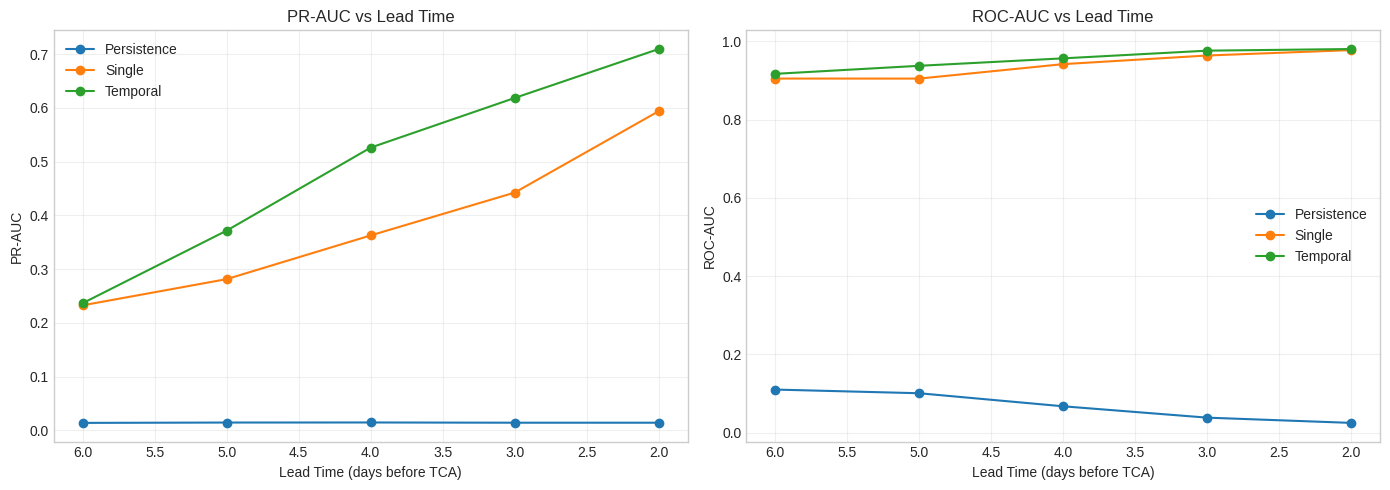

In [102]:
# Create a readable summary focusing on the most important metrics
summary_view = results_all[['Lead_Time', 'Model',
                            'recall_mean', 'precision_mean',
                            'f2_mean', 'roc_auc_mean', 'pr_auc_mean']].copy()

summary_view = summary_view.round(3)
print("="*85)
print("CLEAN SUMMARY (Mean values)")
print("="*85)
print(summary_view.to_string(index=False))

# Plotting: PR-AUC and ROC-AUC vs Lead Time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model in ['Persistence', 'Single', 'Temporal']:
    subset = results_all[results_all['Model'] == model]
    axes[0].plot(subset['Lead_Time'], subset['pr_auc_mean'], marker='o', label=model)
    axes[1].plot(subset['Lead_Time'], subset['roc_auc_mean'], marker='o', label=model)

axes[0].set_title("PR-AUC vs Lead Time")
axes[0].set_xlabel("Lead Time (days before TCA)")
axes[0].set_ylabel("PR-AUC")
axes[0].invert_xaxis()
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("ROC-AUC vs Lead Time")
axes[1].set_xlabel("Lead Time (days before TCA)")
axes[1].set_ylabel("ROC-AUC")
axes[1].invert_xaxis()
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Key Observations

1. The latest available risk value provides a strong baseline for identifying high-risk conjunction events even several days before TCA.

2. The machine-learning models improve upon the persistence baseline in ranking high-risk events, as reflected by the ROC-AUC and PR-AUC results.

3. Incorporating temporal evolution features improves the ranking performance compared with using only the latest available CDM in the evaluated lead-time experiments.

4. The improvement in recall from temporal information is more limited, indicating that identifying additional high-risk events and reducing false alarms remain challenging.

5. Prediction performance generally improves as the prediction point moves closer to the Time of Closest Approach.

6. Overall, the results suggest that information contained in the historical evolution of CDMs can provide useful additional signal for early high-risk event prediction.

## 14. Limitations

The reported results are based on the available dataset and the evaluation setup used in this study. Although repeated cross-validation provides a more stable estimate than a single train-test split, further validation on independent event-level data would be required before drawing conclusions about real-world operational deployment.